# Coupled 2-species reaction–diffusion in d=1 — a multi-field spatial model

**Showcases:** the spatial MSR-JD machinery on a **coupled multi-field** model — two reaction–diffusion species $a,b$ tied by an off-diagonal $(+g,-h)$ reaction matrix. The pipeline solves them on the coupled spectral path (every diagram a weighted sum of scalar chamber integrals). We plot field $a$'s auto-correlator $C_{aa}(\chi,\tau)$ — the coupling to $b$ enters through the loop. Run to **1-loop**.

$$\partial_t a = D\,\partial_x^2 a - \mu_a a - g\,b - g_a a^3 + \eta_a,\qquad \partial_t b = D\,\partial_x^2 b - \mu_b b + h\,a - g_b b^3 + \eta_b,$$
$$\langle\eta_i(x,t)\,\eta_j(x',t')\rangle = 2T_i\,\delta_{ij}\,\delta(x-x')\,\delta(t-t').$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for simulations/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the model file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
MODEL = 'coupled_rd_2species_1d'
model, mod = dd.load_model(MODEL)
dd.describe_model(model, mod);

────────────────────────────────────────────────────────────────────────
  coupled-rd-2species-1d
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : a (x∈ℝ^1); b (x∈ℝ^1)
Response fields: at, bt
Parameters     :
    mua = 1.5  (positive)
    mub = 1.2  (positive)
    Da = 0.8  (positive)
    Db = 0.8  (positive)
    g = 0.4
    h = 0.3
    ga = 0.3
    gb = 0.3
    Ta = 1.0  (positive)
    Tb = 0.7  (positive)
Mean-field saddle (solved by the pipeline): astar, bstar
Action  S      : at*((Dt+mua-Da*Laplacian)*a + g*b + ga*a^3) + bt*((Dt+mub-Db*Laplacian)*b - h*a + gb*b^3) - Ta*at^2 - Tb*bt^2
Suggested run  : k=2, max_ell=1

Coupled 2-species reaction-diffusion in d=1 (the spatial multi-field
demo model).

Two diffusing species ``a(x,t)``, ``b(x,t)`` with a matrix reaction
coupling (an off-diagonal predator-prey pair → a complex eigenvalue pair
→ damped spatio-temporal oscill

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The plot is the **model only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=0,                 # two-point ⟨a a⟩, tree + 1-loop
    external_fields=[('da', 1), ('db', 1)],
    parameters={'mua': 1.5, 'mub': 1.2, 'Da': 0.8, 'Db': 1.2, 'g': 0.4, 'h': 0.3,
                'ga': 0.3, 'gb': 0.3, 'Ta': 1.0, 'Tb': 0.7},
    chi_grid=(0.0, 6.0, 25),    # spatial separations χ ∈ [0, 6]
    tau_grid=(-6.0, 6.0, 51),   # τ grid → adds the C(χ,τ) heatmap + temporal slices
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   spatial_points=...,           # k≥3 spatial: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
  dyson_order=1, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
  parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
  verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)

[1/7] FieldTheory.expand (taylor_order=2)...
[expand-cache] hit at order=4, filtered down to 2
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 0, sources: 2 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        at1  *  (astar1^3*ga + bstar1*g + astar1*mua)
        bt1  *  (bstar1^3*gb - astar1*h + bstar1*mub)

      ── Free action (1,1) bilinear sector ──
        at1·da1  *  (3*astar1^2*ga - Da*Laplacian + Dt + mua)
        bt1·db1  *  (3*bstar1^2*gb - Db*Laplacian + Dt + mub)
        at1·db1  *  (g)
        bt1·da1  *  (-h)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (2,0):
        at1^2  *  (-Ta)
        bt1^2  *  (-Tb)

      [expand] done in 0.71s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...

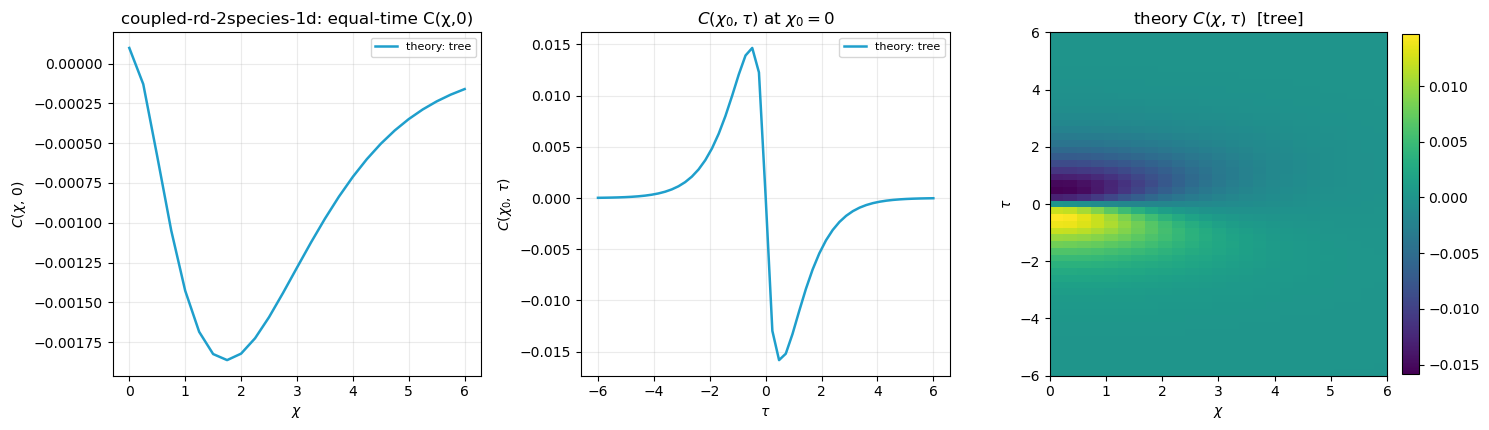

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # model only
plt.show()

## 3. Independent simulation

A direct integration of the coupled SPDE (semi-implicit Euler–Maruyama on a periodic ring) — no reference to the diagrammatics. The reaction and noise matrices are built from the **same model parameters**, so overlaying field $a$'s auto-correlator $C_{aa}(\chi,\tau)$ on the model — equal-time slice, temporal slices, and a matching $C(\chi,\tau)$ heatmap on a shared colour scale — is the validation.

model C_ab(0,0) = +0.00010   sim C_ab(0,0) = -0.00225


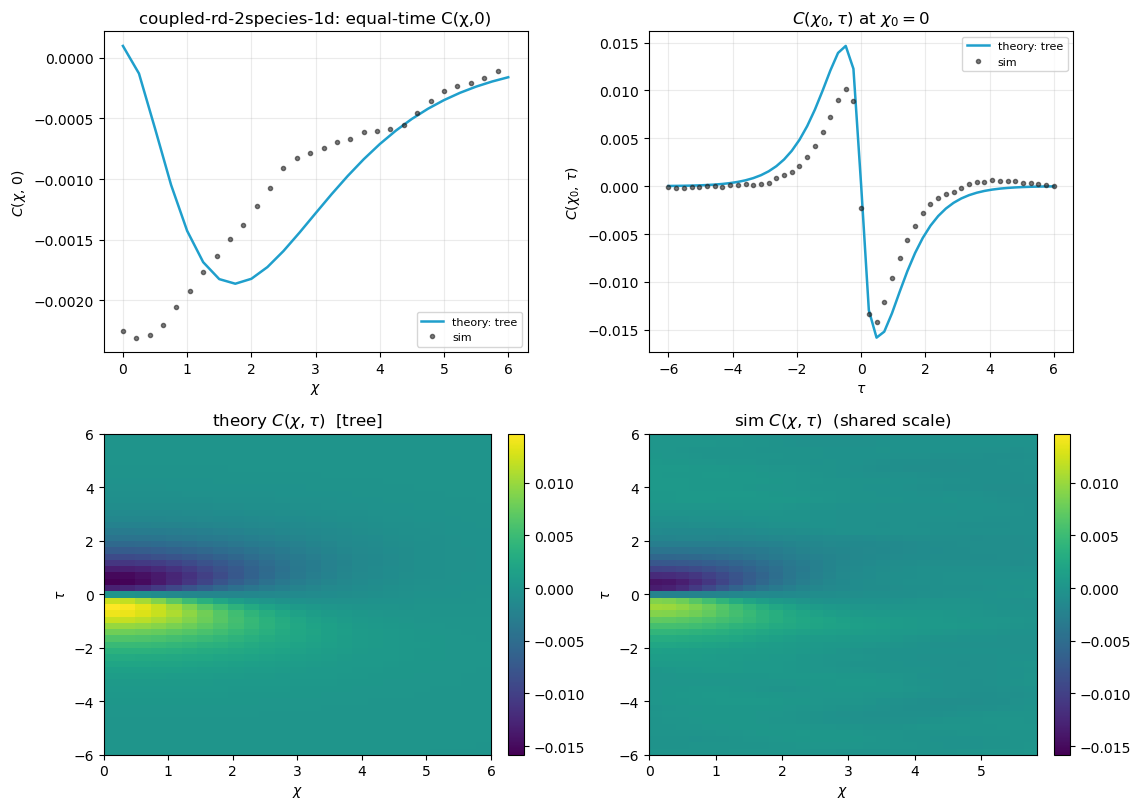

In [5]:
# ── §3 simulation — overlays whichever correlator cfg.external_fields selected ──
# Reuses the existing model `res`/`cfg`; re-runs only the (fast) coupled SPDE sim.
from simulations.coupled_rd_1d_sim import simulate_coupled_rd_1d
fp = dd.parameters_from_model(model)
Mmat   = np.array([[fp['mua'], fp['g']], [-fp['h'], fp['mub']]])   # +g in a-eqn, −h in b-eqn
Nnoise = np.diag([2 * fp['Ta'], 2 * fp['Tb']])
pos = [float(t) for t in np.asarray(res['tau_grid']) if t >= 0]    # τ≥0 lags (C(−τ)=C(τ)ᵀ)
raw = simulate_coupled_rd_1d(Mmat, float(fp['Da']), Nnoise,
                             g=(float(fp['ga']), float(fp['gb'])),
                             L=20.0, n_x=int(96), dt=2e-3, t_burn=50.0, t_run=1000.0,
                             n_rep=int(20), seed=int(3), lags=tuple(pos))

# pick the (i,j) block the config asked for: ('da','db')→C_ab, ('da','da')→C_aa, …
fields = [f[1:] if f.startswith('d') else f for f in dd.field_names(model)]   # e.g. ['a','b']
idx    = {name: k for k, name in enumerate(fields)}
def _fi(leg):
    nm = leg[0] if isinstance(leg, (tuple, list)) else leg
    return idx[nm[1:] if nm.startswith('d') else nm]
ef   = res['_resolved']['external_fields']
i, j = _fi(ef[0]), _fi(ef[1])
lab  = fields[i] + fields[j]

taus = np.asarray(raw['taus']); xg = np.asarray(raw['x_grid'])
half = len(xg) // 2 + 1                                            # χ ≥ 0 half of the ring
mask = xg[:half] <= float(np.asarray(res['spatial_grid']).max())  # clip to the model's χ range
Cij  = np.real(raw['C'][:, i, j, :half])[:, mask]                 # C_ij(χ, τ≥0)
Cji  = np.real(raw['C'][:, j, i, :half])[:, mask]                 # C_ji = C_ij(χ, τ<0)  [C(−τ)=C(τ)ᵀ]
tau_full = np.concatenate([-taus[:0:-1], taus])
C_full   = np.concatenate([Cji[:0:-1], Cij], axis=0)             # τ<0 ← transpose block (auto i==j ⇒ even)
sim = {'x': xg[:half][mask], 'tau': tau_full, 'C': C_full}

mid = int(np.argmin(np.abs(res['tau_grid'])))
print('model C_%s(0,0) = %+.5f   sim C_%s(0,0) = %+.5f'
      % (lab, np.real(res['C_tau_x'])[mid][0], lab, sim['C'][int(np.argmin(np.abs(tau_full)))][0]))
dd.plot_cumulant(res, cfg, model, sim=sim)   # 4 panels — the cfg-selected correlator
plt.show()

## Summary

The coupled tree (matrix Lyapunov correlator, analytic spectral IFT) and the 1-loop cubic-vertex correction both track the independent SPDE simulation for field $a$'s auto-correlator $C_{aa}(\chi,\tau)$. This is the spatial pipeline's **multi-field** mode — every coupled diagram reduced to a weighted sum of scalar chamber integrals — shown here on the same single-correlator footing as the single-field examples (swap `('da',…)` for `('db',…)` or a cross pair `[('da',1),('db',1)]` to probe the other components).